# CVE to CWE Mapping

## Pre reqs:
You need to have ran scrape_cwe.ipynb file and fill the CVE folder in scrapers/scraped_data in order to continue

### Requirements

In [1]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu 
%pip install sentence-transformers pandas tqdm matplotlib

Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from sentence_transformers import SentenceTransformer, CrossEncoder
from sentence_transformers.util import semantic_search, dot_score
import torch
import numpy as np
import json
import pandas as pd
from tqdm import tqdm
from functools import lru_cache
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

2026-08-30 16:41:06.762555: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1788108066.928407     103 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1788108066.975505     103 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1788108067.361914     103 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1788108067.361947     103 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1788108067.361950     103 computation_placer.cc:177] computation placer alr

## Loading scraped data

In [13]:
BASE_DIR = "./CWE_CVE_Mapping" # Kaggle
# BASE_DIR = "../" # Local

### Loading CWE

In [14]:
with open(f"{BASE_DIR}/scrapers/scraped_data/CWE_SOFTWARE.json", "r", encoding="utf-8") as f:
    CWE = json.load(f)

### Loading CVE

In [16]:
CVE_files = ["nvd_2025_cwe699.csv"]

CVE: pd.DataFrame = pd.DataFrame()
for i, file in enumerate(CVE_files):
    if i == 0:
        CVE = pd.read_csv(f"{BASE_DIR}/scrapers/scraped_data/CVE/{file}")
        continue
    
    CVE = pd.concat([CVE, pd.read_csv(f"{BASE_DIR}/scrapers/scraped_data/CVE/{file}")], ignore_index=True)

## Embedding

In [17]:
embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L12-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/352 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [18]:
# CWE Embeddings - Slower because not batching but it's more readable

def extract_description(child):
    description = child["description"]
    if child["extended_description"] is not None:
        description += f"\n{child["extended_description"]}"
        
    return description


for id, category in tqdm(CWE.items()):
    child_descriptions = [extract_description(child) for child in category["children"].values()]
    child_descriptions_embeddings = embedding_model.encode(child_descriptions)
    child_titles = []
    for index, (child_id, child) in enumerate(category["children"].items()):
        child["description_embedding"] = child_descriptions_embeddings[index]
        child_titles.append(child["title"])
    category["summary_embedding"] = embedding_model.encode(category["title"] + ",".join(child_titles) + category["summary"])

100%|██████████| 40/40 [00:01<00:00, 21.09it/s]


In [19]:
np.save("embeddings/CWE_embeddings.npy", CWE)

FileNotFoundError: [Errno 2] No such file or directory: 'embeddings/CWE_embeddings.npy'

In [20]:
# Checking for embeding description values
if len(CVE[CVE["description"].notna() == False]) != 0:
    raise ValueError("Some descriptions in CVE are empty, please check and remove")

In [21]:
# CVE Embeddings
embeddings = embedding_model.encode(
    CVE["description"].tolist(), batch_size=64, show_progress_bar=True
)

Batches:   0%|          | 0/419 [00:00<?, ?it/s]

In [22]:
CVE["description_embeddings"] = list(embeddings)

In [15]:
np.save("embeddings/CVE_embeddings.npy", CVE)

## Cosine similarity for Categories

In [23]:
@lru_cache
def find_category_from_children(child):
    child = child.split("-")[-1]
    for category_id, category in CWE.items():
        if child in list(category["children"].keys()):
            return category_id
    
    raise ValueError(f"Could not find category for child: {child}")
CVE["cwe_699_category"] = CVE["cwe_699_matches"].apply(find_category_from_children)

In [24]:
category_embeddings = [category["summary_embedding"] for category in CWE.values()]

# semantic_search expects queries first, corpus second
hits = semantic_search(torch.tensor(CVE["description_embeddings"].to_list()), torch.tensor(category_embeddings), top_k=len(CWE.keys()))
# hits is a list of length len(CVE), each entry a list of top_k dicts:
# [{'corpus_id': int, 'score': float}, ...]

category_ids = list(CWE.keys()) # adjust key as needed

CVE["top_categories_embeddings"] = [
    [category_ids[hit["corpus_id"]] for hit in row] for row in hits
]
# CVE["top_category_scores"] = [
#     [hit["score"] for hit in row] for row in hits
# ]

/tmp/ipykernel_103/2185994763.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  hits = semantic_search(torch.tensor(CVE["description_embeddings"].to_list()), torch.tensor(category_embeddings), top_k=len(CWE.keys()))


In [24]:
CVE.head(5)

,cve_id,published,last_modified,published_year,description,all_nvd_cwes,cwe_699_matches,number_of_nvd_cwes,number_of_cwe_699_matches,cwe_699_category,description_embeddings,top_categories_embeddings,top_category_scores
0,CVE-2025-0168,2025-01-01T14:15:23.590,2026-06-17T08:26:00.070,2025,A vulnerability classified as critical has bee...,CWE-74|CWE-89,CWE-89,2,1,137,"[-0.06938651, 0.012077127, -0.05567078, -0.016...","[137, 1006, 399, 275, 19, 429, 840, 438, 1210,...","[0.39142531156539917, 0.39018309116363525, 0.3..."
1,CVE-2025-22214,2025-01-02T04:15:06.277,2026-06-17T08:45:38.530,2025,Landray EIS 2001 through 2006 allows Message/f...,CWE-89,CWE-89,1,1,137,"[-0.009580135, 0.0017847966, -0.0633252, 0.043...","[1214, 199, 417, 137, 840, 19, 387, 1227, 1212...","[0.2310275286436081, 0.2226734310388565, 0.205..."
2,CVE-2025-0171,2025-01-02T15:15:25.550,2026-06-17T08:26:00.413,2025,"A vulnerability, which was classified as criti...",CWE-74|CWE-89,CWE-89,2,1,137,"[-0.053881574, 0.06532457, -0.047341105, -0.00...","[1006, 1217, 275, 137, 840, 1216, 399, 1210, 4...","[0.39945775270462036, 0.39650267362594604, 0.3..."
3,CVE-2025-0172,2025-01-02T16:15:09.103,2026-06-17T08:26:00.560,2025,A vulnerability has been found in code-project...,CWE-74|CWE-89,CWE-89,2,1,137,"[-0.054688584, 0.060737424, -0.043001924, -0.0...","[1006, 275, 399, 137, 840, 1217, 310, 1210, 12...","[0.4171420633792877, 0.38705283403396606, 0.37..."
4,CVE-2025-0173,2025-01-02T18:15:21.630,2026-06-17T08:26:00.697,2025,A vulnerability was found in SourceCodester On...,CWE-74|CWE-89,CWE-89,2,1,137,"[-0.110763304, -0.06551826, -0.022899196, 0.01...","[1006, 137, 275, 355, 438, 19, 429, 399, 840, ...","[0.3732925057411194, 0.3399859368801117, 0.332..."


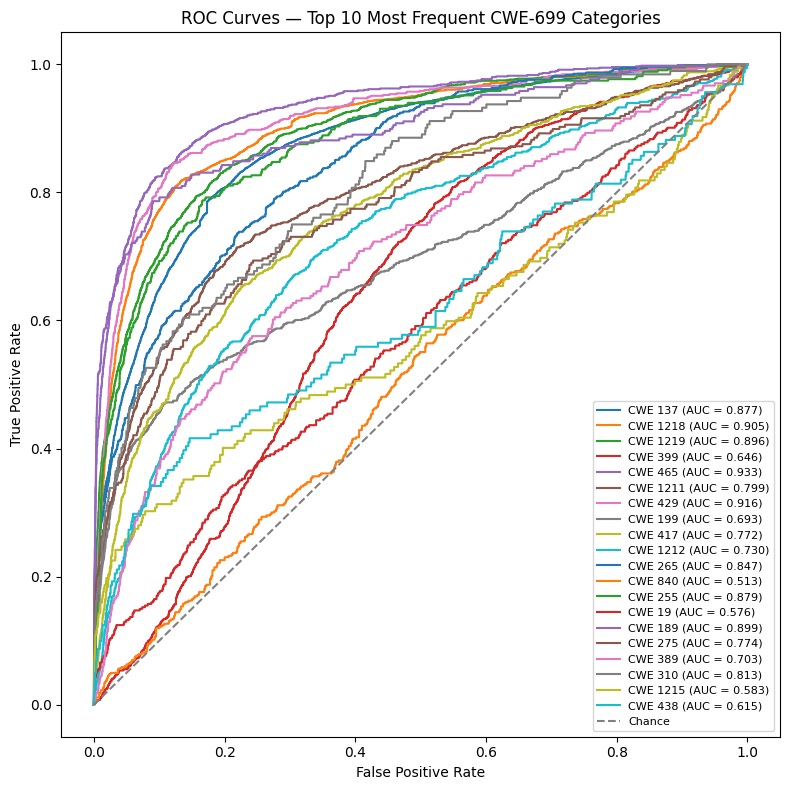

In [25]:


# --- 1. make sure scores are available (uncomment in your original block) ---
CVE["top_category_scores"] = [
    [hit["score"] for hit in row] for row in hits
]

# --- 2. pick the top 10 most frequent ground-truth categories ---
top10_categories = (
    CVE["cwe_699_category"]
    .value_counts()
    .head(20)
    .index
    .tolist()
)

# --- 3. build y_true / y_score per category and plot ROC curves ---
plt.figure(figsize=(8, 8))

for cat in top10_categories:
    y_true = (CVE["cwe_699_category"] == cat).astype(int).to_numpy()

    y_score = []
    for true_cat, preds, scores in zip(
        CVE["cwe_699_category"],
        CVE["top_categories_embeddings"],
        CVE["top_category_scores"],
    ):
        if cat in preds:
            # use the similarity score at the position this category was retrieved
            y_score.append(scores[preds.index(cat)])
        else:
            # category wasn't in the top-10 retrieved for this row -> treat as lowest score
            y_score.append(0.0)
    y_score = np.array(y_score)

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"CWE {cat} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Top 10 Most Frequent CWE-699 Categories")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

Recall@1: 0.422
Recall@2: 0.546
Recall@3: 0.624
Recall@5: 0.725
Recall@10: 0.861


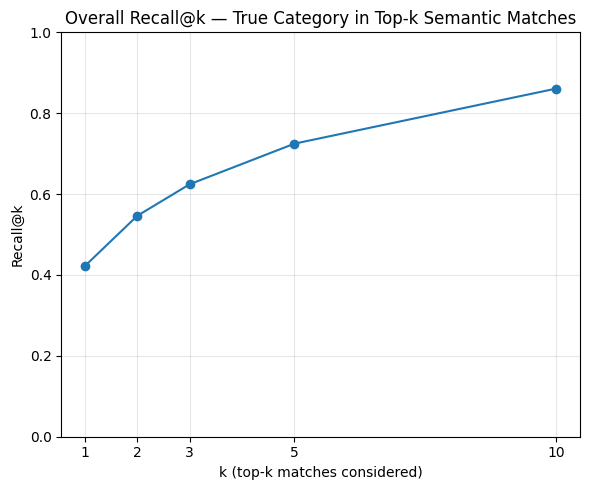

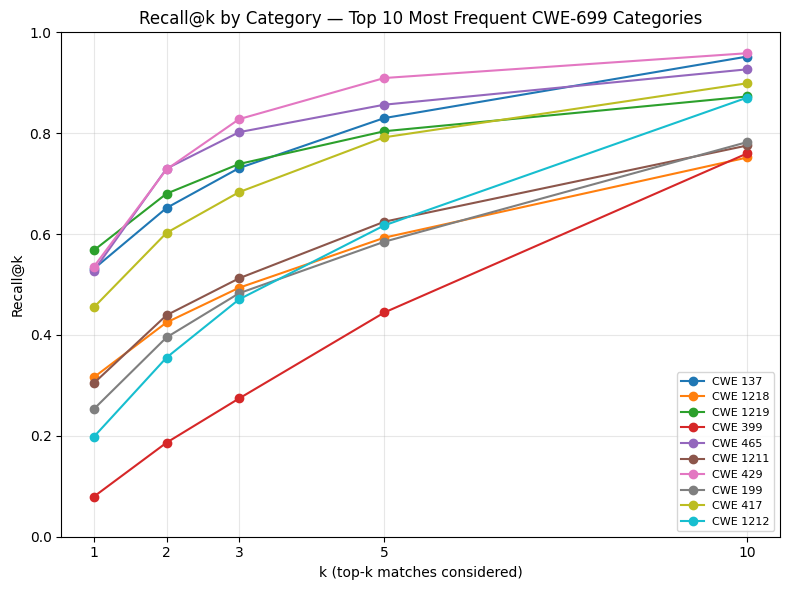

In [26]:
ks = [1, 2, 3, 5, 10]

# --- overall recall@k across ALL CVEs ---
overall_recall = []
for k in ks:
    hits = [
        true_cat in preds[:k]
        for true_cat, preds in zip(CVE["cwe_699_category"], CVE["top_categories_embeddings"])
    ]
    overall_recall.append(np.mean(hits))

for k, r in zip(ks, overall_recall):
    print(f"Recall@{k}: {r:.3f}")

# --- plot overall recall@k ---
plt.figure(figsize=(6, 5))
plt.plot(ks, overall_recall, marker="o")
plt.xticks(ks)
plt.ylim(0, 1)
plt.xlabel("k (top-k matches considered)")
plt.ylabel("Recall@k")
plt.title("Overall Recall@k — True Category in Top-k Semantic Matches")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- per-category recall@k, for top N most frequent categories ---
top_n_categories = (
    CVE["cwe_699_category"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)

plt.figure(figsize=(8, 6))
for cat in top_n_categories:
    subset = CVE[CVE["cwe_699_category"] == cat]
    recall_per_k = []
    for k in ks:
        hits = [cat in preds[:k] for preds in subset["top_categories_embeddings"]]
        recall_per_k.append(np.mean(hits))
    plt.plot(ks, recall_per_k, marker="o", label=f"CWE {cat}")

plt.xticks(ks)
plt.ylim(0, 1)
plt.xlabel("k (top-k matches considered)")
plt.ylabel("Recall@k")
plt.title("Recall@k by Category — Top 10 Most Frequent CWE-699 Categories")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()